In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/ae_features.csv', parse_dates=['WeekEndingDate'])

# Isolate Forth Valley — same development board
fv = df[df['BoardName'] == 'Forth Valley'].sort_values('WeekEndingDate').copy()

print(f"Forth Valley weeks: {len(fv)}")
print(f"Date range: {fv['WeekEndingDate'].min().date()} → {fv['WeekEndingDate'].max().date()}")

Forth Valley weeks: 586
Date range: 2015-02-22 → 2026-05-10


In [2]:
# Prophet dataframe
prophet_df = fv[['WeekEndingDate', 'BreachRate']].copy()
prophet_df.columns = ['ds', 'y']
prophet_df['y'] = prophet_df['y'].clip(lower=0.001, upper=0.999)

# Train/test split — same as SARIMAX for fair comparison
train_p = prophet_df[prophet_df['ds'] < '2023-01-01'].copy()
test_p  = prophet_df[prophet_df['ds'] >= '2023-01-01'].copy()

print(f"Train: {len(train_p)} weeks")
print(f"Test:  {len(test_p)} weeks")
print(train_p.tail(3))

Train: 410 weeks
Test:  176 weeks
             ds         y
2165 2022-12-11  0.612466
2166 2022-12-18  0.625000
2167 2022-12-25  0.488281


In [3]:
# Prophet accepts a holidays dataframe with 'ds' and 'holiday' columns
school_holiday_dates = fv[fv['IsSchoolHoliday'] == 1]['WeekEndingDate'].tolist()

holidays_df = pd.DataFrame({
    'ds':      pd.to_datetime(school_holiday_dates),
    'holiday': 'ScottishSchoolHoliday'
})

# Add COVID structural break as a one-off holiday event
covid_start = pd.DataFrame({
    'ds':      [pd.Timestamp('2020-03-16')],
    'holiday': ['CovidLockdownStart'],
    'lower_window': [0],
    'upper_window': [7],
})

post_covid = pd.DataFrame({
    'ds':      [pd.Timestamp('2022-04-01')],
    'holiday': ['PostCovidPressureOnset'],
    'lower_window': [0],
    'upper_window': [30],
})

all_holidays = pd.concat([holidays_df, covid_start, post_covid], ignore_index=True)
print(f"Holiday events: {len(all_holidays)}")
print(all_holidays['holiday'].value_counts())

Holiday events: 210
holiday
ScottishSchoolHoliday     208
CovidLockdownStart          1
PostCovidPressureOnset      1
Name: count, dtype: int64


In [4]:
m_baseline = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,   # we have weekly data, not daily
    daily_seasonality=False,
    holidays=all_holidays,
    seasonality_mode='additive',
    changepoint_prior_scale=0.3,   # flexible — allows COVID-era changepoints
    seasonality_prior_scale=10,
    interval_width=0.95
)

m_baseline.fit(train_p)
print("Prophet baseline fitted ✓")

# Forecast over test period
future_baseline = m_baseline.make_future_dataframe(
    periods=len(test_p), freq='W', include_history=True
)
forecast_baseline = m_baseline.predict(future_baseline)

# Extract test period predictions
pred_baseline = forecast_baseline[
    forecast_baseline['ds'] >= '2023-01-01'
][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].reset_index(drop=True)

pred_baseline['yhat'] = pred_baseline['yhat'].clip(0, 1)

actual = test_p['y'].values

def metrics(actual, predicted, label):
    predicted = np.array(predicted)
    mape = np.mean(np.abs((actual - predicted) / np.clip(actual, 0.01, None))) * 100
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    print(f"\n=== {label} ===")
    print(f"  MAPE : {mape:.2f}%")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    return mape, rmse, mae

mape_pb, rmse_pb, mae_pb = metrics(actual, pred_baseline['yhat'].values,
                                    "Prophet Baseline")

18:41:19 - cmdstanpy - INFO - Chain [1] start processing
18:41:22 - cmdstanpy - INFO - Chain [1] done processing


Prophet baseline fitted ✓

=== Prophet Baseline ===
  MAPE : 66.51%
  RMSE : 0.3762
  MAE  : 0.3541


In [5]:
exog_cols = [
    'CovidEra', 'PostCovidStress', 'FluSeasonFlag',
    'WinterFlag', 'IsSchoolHoliday', 'StaffingPressureFlag', 'FluSearchIndex'
]

# Build prophet dataframe with regressors
prophet_df_exog = fv[['WeekEndingDate', 'BreachRate'] + exog_cols].copy()
prophet_df_exog.columns = ['ds', 'y'] + exog_cols
prophet_df_exog['y'] = prophet_df_exog['y'].clip(lower=0.001, upper=0.999)
prophet_df_exog[exog_cols] = prophet_df_exog[exog_cols].ffill()

train_pe = prophet_df_exog[prophet_df_exog['ds'] < '2023-01-01'].copy()
test_pe  = prophet_df_exog[prophet_df_exog['ds'] >= '2023-01-01'].copy()

# Build and fit model with regressors
m_exog = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    holidays=all_holidays,
    seasonality_mode='additive',
    changepoint_prior_scale=0.3,
    seasonality_prior_scale=10,
    interval_width=0.95
)

for col in exog_cols:
    m_exog.add_regressor(col)

m_exog.fit(train_pe)
print("Prophet + regressors fitted ✓")

# Forecast
forecast_exog = m_exog.predict(test_pe)
forecast_exog['yhat'] = forecast_exog['yhat'].clip(0, 1)

mape_pe, rmse_pe, mae_pe = metrics(actual, forecast_exog['yhat'].values,
                                    "Prophet + Exogenous Regressors")

print(f"\n--- Prophet vs SARIMAX best ---")
print(f"  Prophet MAPE: {mape_pe:.2f}%  vs  SARIMAX MAPE: 67.30%")

18:41:34 - cmdstanpy - INFO - Chain [1] start processing
18:41:35 - cmdstanpy - INFO - Chain [1] done processing


Prophet + regressors fitted ✓

=== Prophet + Exogenous Regressors ===
  MAPE : 67.74%
  RMSE : 0.3826
  MAE  : 0.3606

--- Prophet vs SARIMAX best ---
  Prophet MAPE: 67.74%  vs  SARIMAX MAPE: 67.30%


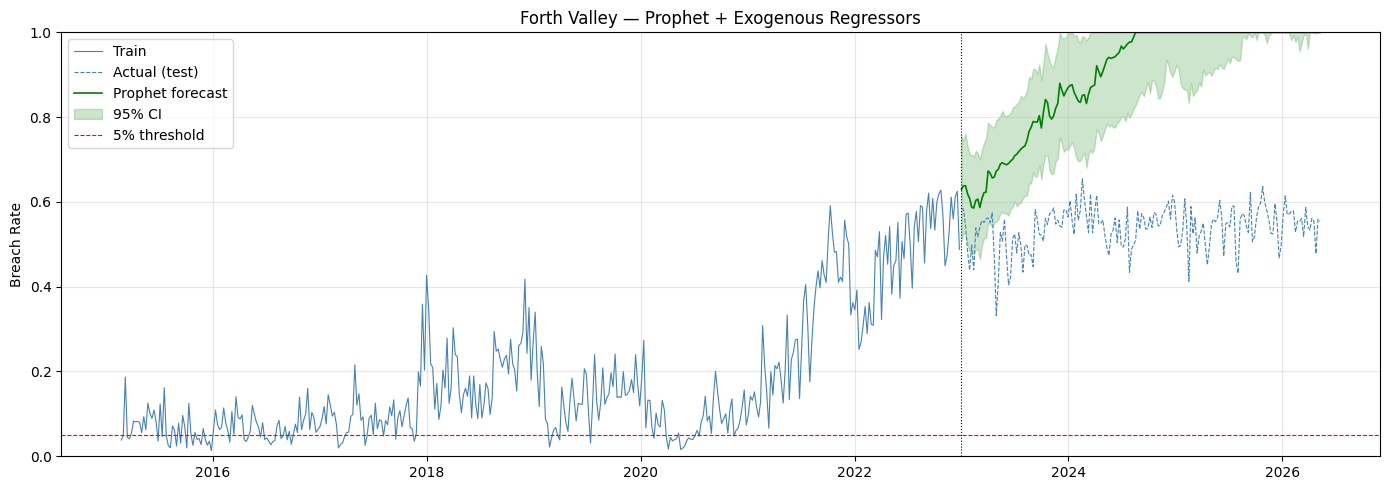

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train_p['ds'], train_p['y'],
        color='steelblue', linewidth=0.8, label='Train')
ax.plot(test_p['ds'], test_p['y'],
        color='steelblue', linewidth=0.8, linestyle='--', label='Actual (test)')
ax.plot(forecast_exog['ds'], forecast_exog['yhat'],
        color='green', linewidth=1.2, label='Prophet forecast')
ax.fill_between(forecast_exog['ds'],
                forecast_exog['yhat_lower'].clip(0, 1),
                forecast_exog['yhat_upper'].clip(0, 1),
                alpha=0.2, color='green', label='95% CI')
ax.axhline(0.05, color='red', linestyle='--', linewidth=0.8, label='5% threshold')
ax.axvline(pd.Timestamp('2023-01-01'), color='black', linestyle=':', linewidth=0.8)
ax.set_title('Forth Valley — Prophet + Exogenous Regressors')
ax.set_ylabel('Breach Rate')
ax.set_ylim(0, 1)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/fv_prophet_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Use logistic growth with a carrying capacity
# This tells Prophet the breach rate cannot keep rising indefinitely
prophet_df_cap = train_pe.copy()
prophet_df_cap['cap']   = 0.85   # hard ceiling — no board sustains >85% breach rate
prophet_df_cap['floor'] = 0.0

test_pe_cap = test_pe.copy()
test_pe_cap['cap']   = 0.85
test_pe_cap['floor'] = 0.0

m_logistic = Prophet(
    growth='logistic',
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    holidays=all_holidays,
    seasonality_mode='additive',
    changepoint_prior_scale=0.05,   # less flexible — prevents over-extrapolation
    seasonality_prior_scale=10,
    interval_width=0.95
)

for col in exog_cols:
    m_logistic.add_regressor(col)

m_logistic.fit(prophet_df_cap)
print("Prophet logistic fitted ✓")

forecast_logistic = m_logistic.predict(test_pe_cap)
forecast_logistic['yhat'] = forecast_logistic['yhat'].clip(0, 1)

mape_pl, rmse_pl, mae_pl = metrics(actual, forecast_logistic['yhat'].values,
                                    "Prophet Logistic Growth + Cap")

print(f"\n--- All models so far ---")
print(f"  SARIMAX + exog:          MAPE {67.30:.2f}%")
print(f"  Prophet baseline:        MAPE {mape_pb:.2f}%")
print(f"  Prophet + exog:          MAPE {mape_pe:.2f}%")
print(f"  Prophet logistic + cap:  MAPE {mape_pl:.2f}%")

18:55:49 - cmdstanpy - INFO - Chain [1] start processing
18:55:50 - cmdstanpy - INFO - Chain [1] done processing


Prophet logistic fitted ✓

=== Prophet Logistic Growth + Cap ===
  MAPE : 28.45%
  RMSE : 0.1604
  MAE  : 0.1487

--- All models so far ---
  SARIMAX + exog:          MAPE 67.30%
  Prophet baseline:        MAPE 66.51%
  Prophet + exog:          MAPE 67.74%
  Prophet logistic + cap:  MAPE 28.45%


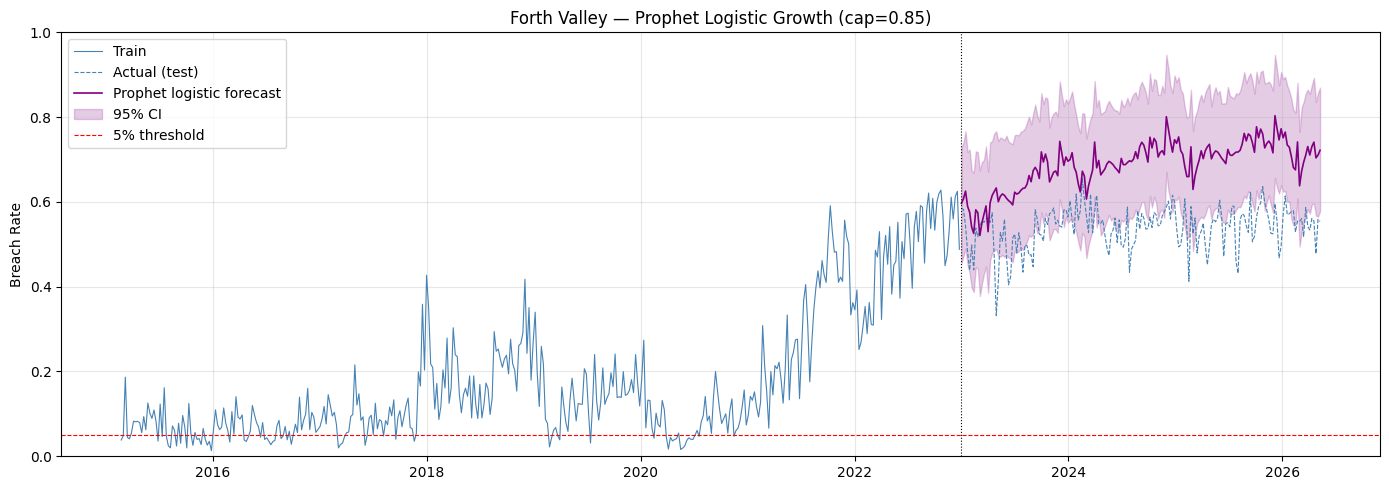

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train_p['ds'], train_p['y'],
        color='steelblue', linewidth=0.8, label='Train')
ax.plot(test_p['ds'], test_p['y'],
        color='steelblue', linewidth=0.8, linestyle='--', label='Actual (test)')
ax.plot(forecast_logistic['ds'], forecast_logistic['yhat'],
        color='purple', linewidth=1.2, label='Prophet logistic forecast')
ax.fill_between(forecast_logistic['ds'],
                forecast_logistic['yhat_lower'].clip(0, 1),
                forecast_logistic['yhat_upper'].clip(0, 1),
                alpha=0.2, color='purple', label='95% CI')
ax.axhline(0.05, color='red', linestyle='--', linewidth=0.8, label='5% threshold')
ax.axvline(pd.Timestamp('2023-01-01'), color='black', linestyle=':', linewidth=0.8)
ax.set_title('Forth Valley — Prophet Logistic Growth (cap=0.85)')
ax.set_ylabel('Breach Rate')
ax.set_ylim(0, 1)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/fv_prophet_logistic.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Add regime feature to all prophet dataframes
fv['PostCovidPlateau'] = (
    (fv['WeekEndingDate'] >= '2022-04-01') &
    (fv['WeekEndingDate'] < '2023-01-01')   # only in training — model learns the level
).astype(float)

# Plateau level for test: sustained high pressure
fv.loc[fv['WeekEndingDate'] >= '2023-01-01', 'PostCovidPlateau'] = 1.0

exog_cols_v2 = exog_cols + ['PostCovidPlateau']

prophet_df_v2 = fv[['WeekEndingDate', 'BreachRate'] + exog_cols_v2].copy()
prophet_df_v2.columns = ['ds', 'y'] + exog_cols_v2
prophet_df_v2['y']    = prophet_df_v2['y'].clip(lower=0.001, upper=0.999)
prophet_df_v2[exog_cols_v2] = prophet_df_v2[exog_cols_v2].ffill()
prophet_df_v2['cap']   = 0.85
prophet_df_v2['floor'] = 0.0

train_v2 = prophet_df_v2[prophet_df_v2['ds'] < '2023-01-01'].copy()
test_v2  = prophet_df_v2[prophet_df_v2['ds'] >= '2023-01-01'].copy()

m_v2 = Prophet(
    growth='logistic',
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    holidays=all_holidays,
    seasonality_mode='additive',
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10,
    interval_width=0.95
)

for col in exog_cols_v2:
    m_v2.add_regressor(col)

m_v2.fit(train_v2)
forecast_v2 = m_v2.predict(test_v2)
forecast_v2['yhat'] = forecast_v2['yhat'].clip(0, 1)

mape_v2, rmse_v2, mae_v2 = metrics(actual, forecast_v2['yhat'].values,
                                    "Prophet Logistic + PostCovidPlateau feature")

19:03:24 - cmdstanpy - INFO - Chain [1] start processing
19:03:24 - cmdstanpy - INFO - Chain [1] done processing



=== Prophet Logistic + PostCovidPlateau feature ===
  MAPE : 28.98%
  RMSE : 0.1631
  MAE  : 0.1515


In [10]:
results = pd.read_csv('../data/processed/model_results.csv')

prophet_results = pd.DataFrame({
    'Model': ['Prophet Baseline', 'Prophet + Exog', 
              'Prophet Logistic + Cap', 'Prophet Logistic + Plateau'],
    'MAPE':  [66.51, 67.74, 28.45, 28.98],
    'RMSE':  [0.3762, 0.3826, 0.1604, 0.1631],
    'MAE':   [0.3541, 0.3606, 0.1487, 0.1515],
    'Board': ['Forth Valley'] * 4,
    'Notes': [
        'Additive growth, holidays only',
        'Additive growth + exog regressors',
        'Logistic growth cap=0.85 — BEST Prophet variant',
        'Logistic + PostCovidPlateau feature — marginal degradation'
    ]
})

results = pd.concat([results, prophet_results], ignore_index=True)
results.to_csv('../data/processed/model_results.csv', index=False)
print("Prophet results saved ✓")
print(results[['Model','MAPE','RMSE','MAE']].to_string())

Prophet results saved ✓
                        Model   MAPE    RMSE     MAE
0            SARIMAX Baseline  71.77  0.4319  0.3836
1              SARIMAX + Exog  67.30  0.4061  0.3595
2            Prophet Baseline  66.51  0.3762  0.3541
3              Prophet + Exog  67.74  0.3826  0.3606
4      Prophet Logistic + Cap  28.45  0.1604  0.1487
5  Prophet Logistic + Plateau  28.98  0.1631  0.1515
